In [1]:
import cv2 as cv
import sys

import numpy as np

cap = cv.VideoCapture(0, cv.CAP_DSHOW)

if not cap.isOpened():
    sys.exit('카메라 연결 실패')

frames = []

while True:
    ret, frame = cap

    if not ret:
        print('프레임 읽기 실패')
        break

    cv.imshow('frame', frame)

    key = cv.waitKey(1)
    if key == ord('c'):
        frames.append(frame)
    elif key == ord('q'):
        break

cap.release()
cv.destroyAllWindows()

if len(frames) > 0:
    imgs = frames[0]
    for i in range(1, min(3, len(frames))):
        imgs = np.hstack((imgs, frames[i]))

    cv.imshow('Collected Frames', imgs)

    cv.waitKey(0)
    cv.destroyAllWindows()

TypeError: cannot unpack non-iterable cv2.VideoCapture object

In [18]:
import cv2 as cv
import sys

img = cv.imread('dino.jpg')

if img is None:
    sys.exit('이미지 파일 읽기 실패')

cv.rectangle(img, (40, 80), (150, 180), (0, 0, 255), 2)
cv.putText(img, 'Smile', (40, 75), cv.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

cv.imshow('Annotated Image', img)

cv.waitKey()
cv.destroyAllWindows()

In [21]:
import cv2 as cv
import sys

img = cv.imread('dino.jpg')

if img is None:
    sys.exit('이미지 파일 읽기 실패')

def draw(event, x, y, flags, param):
    if event == cv.EVENT_LBUTTONDOWN:
        cv.rectangle(img, (x, y), (x+50, y+50), (0, 0, 255), 2)
    elif event == cv.EVENT_RBUTTONDOWN:
        cv.rectangle(img, (x, y), (x+50, y+50), (255, 0, 0), 2)
    
    cv.imshow('Drawing', img)

cv.namedWindow('Drawing')
cv.imshow('Drawing', img)
cv.setMouseCallback('Drawing', draw)

while True:
    if cv.waitKey(1) == ord('q'):
        cv.destroyAllWindows()
        break

In [24]:
import cv2 as cv
import sys

img = cv.imread('dino.jpg')

if img is None:
    sys.exit('이미지 파일 읽기 실패')

def draw(event, x, y, flags, param):
    global ix, iy

    if event == cv.EVENT_LBUTTONDOWN:
        ix, iy = x, y
    elif event == cv.EVENT_LBUTTONUP:
        cv.rectangle(img, (ix, iy), (x, y), (255, 0, 0), 2)
    
    cv.imshow('edit photo', img)

cv.namedWindow('edit photo')
cv.imshow('edit photo', img)
cv.setMouseCallback('edit photo', draw)

while True:
    if cv.waitKey(1) == ord('q'):
        cv.destroyAllWindows()
        break

In [26]:
import cv2 as cv
import sys

img = cv.imread('dino.jpg')

if img is None:
    sys.exit('이미지 파일 읽기 실패')

BrushSize = 5
Lcolor, Rcolor = (255, 0, 0), (0, 0, 255)

def painting(event, x, y, flags, param):
    if event == cv.EVENT_LBUTTONDOWN:
        cv.circle(img, (x, y), BrushSize, Lcolor, -1)
    elif event == cv.EVENT_MOUSEMOVE and flags == cv.EVENT_FLAG_LBUTTON:
        cv.circle(img, (x, y), BrushSize, Lcolor, -1)
    
    elif event == cv.EVENT_RBUTTONDOWN:
        cv.circle(img, (x, y), BrushSize, Rcolor, -1)
    elif event == cv.EVENT_MOUSEMOVE and flags == cv.EVENT_FLAG_RBUTTON: 
        cv.circle(img, (x, y), BrushSize, Rcolor, -1)
    
    cv.imshow('Painting', img)

cv.namedWindow('Painting')
cv.imshow('Painting', img)
cv.setMouseCallback('Painting', painting)

while True:
    if cv.waitKey(1) == ord('q'):
        cv.destroyAllWindows()
        break

KeyboardInterrupt: 

In [28]:
import cv2 as cv
import numpy as np

img = cv.imread('dino.jpg')
print("shape : ", img.shape)
print("min : " , img.min())
print("max : " , img.max())
print("mean : ", img.mean())

print("max point : ", np.argmax(img))
print("정렬 후 앞부분 : ", np.sort(img, axis=None)[:10])

transposed = np.transpose(img, (1, 0, 2))
print("가로 세로 변환 후 모양 : ", transposed.shape)

cv.imshow('Original', img)
cv.imshow('Transposed', transposed)

cv.waitKey()
cv.destroyAllWindows()

shape :  (400, 300, 3)
min :  0
max :  255
mean :  185.34318333333334
max point :  108345
정렬 후 앞부분 :  [0 0 0 0 0 0 0 0 0 0]
가로 세로 변환 후 모양 :  (300, 400, 3)


In [1]:
import cv2 as cv
import sys

img = cv.imread('dino.jpg')

if img is None:
    sys.exit('이미지 파일 읽기 실패')

cv.imshow('Original Image', img)
cv.imshow('upper left half', img[0:img.shape[0]//2, 0:img.shape[1]//2])
cv.imshow('center half', img[img.shape[0]//4:3*img.shape[0]//4, img.shape[1]//4:3*img.shape[1]//4, :])

cv.imshow('R', img[:,:,2])
cv.imshow('G', img[:,:,1])
cv.imshow('B', img[:,:,0])

cv.waitKey()
cv.destroyAllWindows()


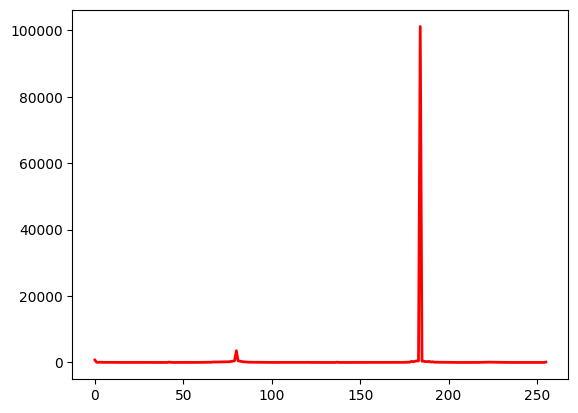

In [9]:
import matplotlib.pyplot as plt
import cv2 as cv

img = cv.imread('dino.jpg')
h = cv.calcHist([img], [2], None, [256], [0, 256])
plt.plot(h, color='r', linewidth=2)

In [11]:
import cv2 as cv
import sys

img = cv.imread('dino.jpg')

t, bin_img = cv.threshold(img[:, :, 2], 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
print('오츄 알고리즘 임계값 : ', t)

cv.imshow('R', img[:, :, 2])
cv.imshow('R binary', bin_img)

cv.waitKey()
cv.destroyAllWindows()

오츄 알고리즘 임계값 :  126.0
